<a href="https://colab.research.google.com/github/uday367/deep-learning/blob/main/Denoising_autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - loss: 0.2653 - val_loss: 0.2098
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.1859 - val_loss: 0.1713
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 0.1653 - val_loss: 0.1583
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1555 - val_loss: 0.1513
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.1495 - val_loss: 0.1457
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.1444 - val_loss: 0.1413
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1401 - val_loss: 0.1381
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.1371 - val_loss: 0.1351
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.1345 - val_loss: 0.1334
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1326 - val_loss: 0.1322
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


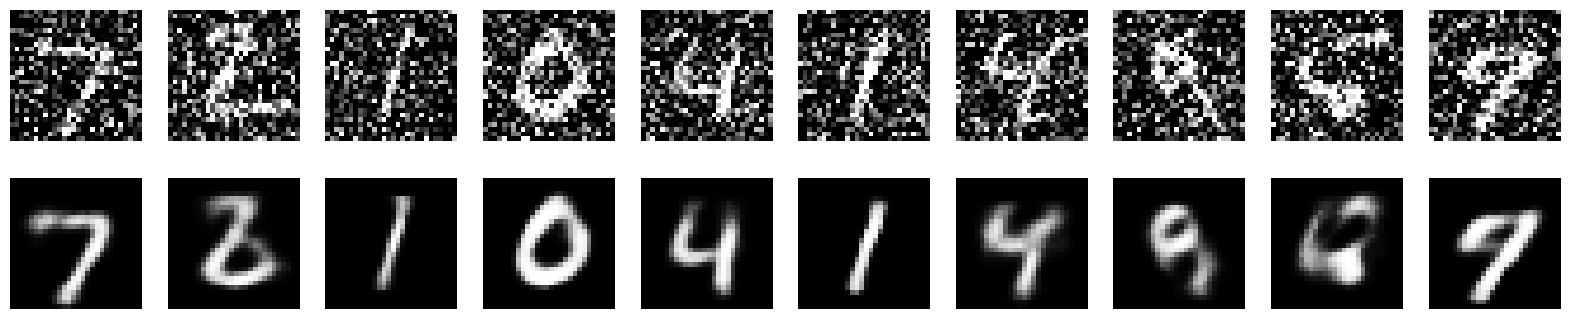

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

# Load MNIST
(x_train,_),(x_test,_) = tf.keras.datasets.mnist.load_data()

# Normalize
x_train = x_train/255.0
x_test = x_test/255.0

# Add noise
noise = 0.5
x_train_noisy = np.clip(x_train + noise*np.random.normal(size=x_train.shape),0,1)
x_test_noisy = np.clip(x_test + noise*np.random.normal(size=x_test.shape),0,1)

# Flatten
x_train = x_train.reshape(-1,784)
x_test = x_test.reshape(-1,784)
x_train_noisy = x_train_noisy.reshape(-1,784)
x_test_noisy = x_test_noisy.reshape(-1,784)

# Autoencoder
inp = layers.Input(shape=(784,))
x = layers.Dense(128,activation='relu')(inp)
x = layers.Dense(64,activation='relu')(x)
x = layers.Dense(32,activation='relu')(x)

x = layers.Dense(64,activation='relu')(x)
x = layers.Dense(128,activation='relu')(x)
out = layers.Dense(784,activation='sigmoid')(x)

model = models.Model(inp,out)
model.compile(optimizer='adam',loss='binary_crossentropy')

# Train
model.fit(x_train_noisy,x_train,epochs=10,batch_size=256,validation_data=(x_test_noisy,x_test))

# Predict
decoded = model.predict(x_test_noisy)

# Plot
n=10
plt.figure(figsize=(20,4))
for i in range(n):
    plt.subplot(2,n,i+1)
    plt.imshow(x_test_noisy[i].reshape(28,28),cmap='gray'); plt.axis('off')

    plt.subplot(2,n,i+n+1)
    plt.imshow(decoded[i].reshape(28,28),cmap='gray'); plt.axis('off')

plt.show()